# **Lab 7.2 CNN**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return `DataLoader()` and print the information about the Dataset.
This function must load only a pair of classes from the entire dataset.
Please ensure that the final image is in grayscale and has a size of 28x28.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomRotation(),`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>)

In [2]:
from collections import Counter
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        lambda x: 1-x,
        transforms.Pad(padding=32),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.CenterCrop((32, 32)),
    ])
    
    class OneHotDataset:
        def __init__(self, dataset):
            self.dataset = dataset
            self.num_classes = len(dataset.classes)
            self.class_to_idx = dataset.class_to_idx
        
        def __len__(self):
            return len(self.dataset)
        
        def __getitem__(self, idx):
            data, label = self.dataset[idx]
            one_hot_label = torch.zeros(self.num_classes)
            one_hot_label[label] = 1
            one_hot_label = torch.tensor(one_hot_label.tolist())
            return data, one_hot_label
            

    dataset = ImageFolder(root=path, transform=transform)
    onehot_dataset = OneHotDataset(dataset)

    data_loader = DataLoader(onehot_dataset, batch_size=16, shuffle=True, num_workers=16, pin_memory=True)
    
    return data_loader

    ### END CODE HERE ###

Use your `load_data()` function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class 0: 313
	Number of images in class 1: 308
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 0: 75
	Number of images in class 1: 81
	Number of testing samples: 156
```


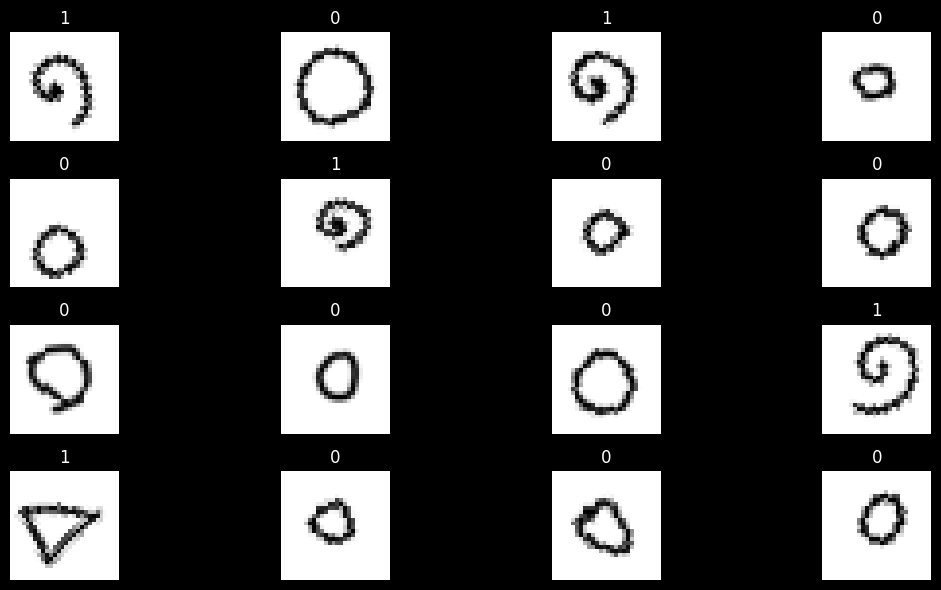

</details>

In [3]:
img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/thai-handwriting-number.appspot.com/0/0a8e39b3-4d7c-4050-a25d-746a6b8de686.png')
print(np.max(img))

1.0


Number of images for class 0: 3882
Number of samples: 3882


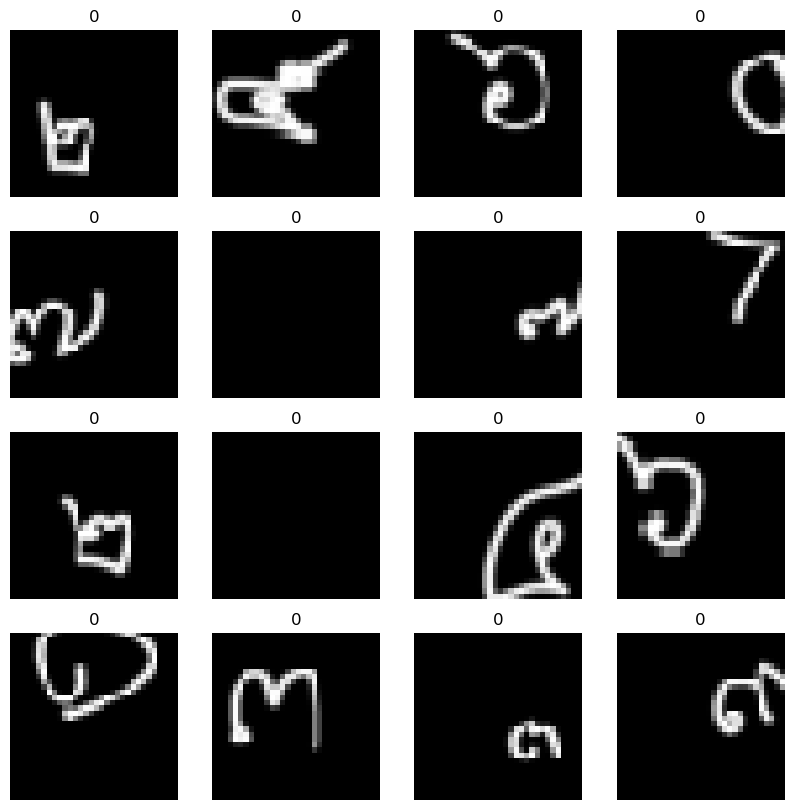

In [4]:
### START CODE HERE ###
data_dir = '/home/crueang/Chaks/image_processing-2024/data/thai-handwriting-number.appspot.com'

data_loader = load_data(data_dir)
features, labels = next(iter(data_loader))

def one_hot_to_class(one_hot_tensor):
    class_index = torch.argmax(one_hot_tensor[0]).item()
    return class_index

dataset = data_loader.dataset
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
classes = [one_hot_to_class(label) for _, label in dataset]
classes = Counter(classes)
for c in classes:
    print(f'Number of images for class {c}: {classes[c]}')
print(f'Number of samples: {len(dataset)}')

fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(features[i].permute(1, 2, 0), cmap='gray')
    ax.set_title(one_hot_to_class(labels[i]))
    ax.axis('off')

### END CODE HERE ###

### **Create Models**
**CustomLeNet**:
- **Input**:  RGB images
- **Architecture**: Multiple convolutional layers with ReLU activations, followed by fully connected layers with ReLU activations
- **Description**: This is a convolutional neural network with two convolutional layers followed by two fully connected layers. It applies convolutional operations with ReLU activations, followed by flattening the output and passing through fully connected layers with ReLU activations. Finally, it produces a 10 neurons output.


In [5]:
### START CODE HERE ###
import torchvision
from torchsummary import summary
class CustomLeNet(nn.Module):
    def __init__(self):
        super(CustomLeNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x
        

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CustomLeNet().to(device)
summary(model, (1, 32, 32))
### END CODE HERE ###

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
       BatchNorm2d-2            [-1, 6, 28, 28]              12
              ReLU-3            [-1, 6, 28, 28]               0
         AvgPool2d-4            [-1, 6, 14, 14]               0
            Conv2d-5           [-1, 16, 10, 10]           2,416
       BatchNorm2d-6           [-1, 16, 10, 10]              32
              ReLU-7           [-1, 16, 10, 10]               0
         AvgPool2d-8             [-1, 16, 5, 5]               0
           Flatten-9                  [-1, 400]               0
           Linear-10                  [-1, 120]          48,120
             ReLU-11                  [-1, 120]               0
           Linear-12                   [-1, 84]          10,164
             ReLU-13                   [-1, 84]               0
           Linear-14                   



Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the training loss/accuracy, test loss/accuracy. Additionally, it should save the model at the last epoch.

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>)


In [6]:
### START CODE HERE ###
import os
def train(model, opt, loss_fn, train_loader, test_loader, epochs=10, checkpoint_path=None, device='cpu'):

    training_logs = {"train_loss": [], "validate_loss": [], "train_acc": [], "validate_acc": []}
    epoch_number = 0
    best_test_loss = float('inf')
    model = model.to(device)

    if checkpoint_path:
      if os.path.exists(checkpoint_path + 'model.pth'):
        model.load_state_dict(torch.load(checkpoint_path + 'model.pth', weights_only=True, map_location=device))

      if os.path.exists(checkpoint_path + 'opt.pth'):
        opt.load_state_dict(torch.load(checkpoint_path + 'opt.pth', weights_only=True, map_location=device))

      if os.path.exists(checkpoint_path + 'training_logs.pth'):
        training_logs = torch.load(checkpoint_path + 'training_logs.pth', weights_only=True)
        epoch_number = len(training_logs['train_loss'])
        best_test_loss = min(best_test_loss, min(training_logs['validate_loss']))

    for i in range(epoch_number):
        print(f"Epochs {i+1}".ljust(10), end='')
        for k, v in training_logs.items():
            print(f"{k}: {v[i]:.5f}", end=" ")
        print()

    print("🤖Training on", device)
    for epoch in range(epoch_number, epochs):

        train_loss, train_correct = 0, 0
        model.train()
        train_bar = tqdm(train_loader, desc=f'🚀Training Epoch [{epoch+1}/{epochs}]', unit='batch')
        for images, label in train_bar:
            images = images.to(device)
            label = label.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, label)
            loss.backward()
            opt.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == label.argmax(1)).float().sum().item()
            
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_train_acc = train_correct / len(train_loader.dataset)
        print(f'\n\tTrain loss: {avg_train_loss}')
        print(f'\tTrain acc: {avg_train_acc}')
        training_logs["train_loss"].append(avg_train_loss)
        training_logs["train_acc"].append(avg_train_acc)

        test_loss, test_correct = 0, 0
        model.eval()
        test_bar = tqdm(test_loader,desc='📄Testing',unit='batch')
        with torch.no_grad():
          for images, label in test_bar:
            images = images.to(device)
            label = label.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, label)

            test_loss += loss.item()
            test_correct += (outputs.argmax(1) == label.argmax(1)).float().sum().item()
            
        avg_test_loss = test_loss / len(test_loader.dataset)
        avg_test_acc = test_correct / len(test_loader.dataset)
        print(f'\tTest loss: {avg_test_loss}')
        print(f'\tTest acc: {avg_test_acc}')
        training_logs["validate_loss"].append(avg_test_loss)
        training_logs["validate_acc"].append(avg_test_acc)

        if checkpoint_path:
            torch.save(model.state_dict(), checkpoint_path + "model.pth")
            torch.save(opt.state_dict(), checkpoint_path + "opt.pth")
            torch.save(training_logs, checkpoint_path + 'training_logs.pth')
            if best_test_loss > avg_test_loss:
               torch.save(model.state_dict(), checkpoint_path + "best_model.pth")
               best_test_loss = avg_test_loss

### END CODE HERE ###

Use your `train()` function to train models.

In [7]:
### START CODE HERE ###
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
train_set, test_set = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)
train(model, optimizer, criterion, train_loader, test_loader, epochs=50, checkpoint_path='/home/crueang/Chaks/image_processing-2024/Lab7_Data-Augmentation-CNN/cp/',device=device)

### END CODE HERE ###

Epochs 1  train_loss: 0.14112 validate_loss: 0.13631 train_acc: 0.14456 validate_acc: 0.22036 
Epochs 2  train_loss: 0.13244 validate_loss: 0.13481 train_acc: 0.23181 validate_acc: 0.19588 
Epochs 3  train_loss: 0.12509 validate_loss: 0.12131 train_acc: 0.30296 validate_acc: 0.36985 
Epochs 4  train_loss: 0.12024 validate_loss: 0.11851 train_acc: 0.35995 validate_acc: 0.40335 
Epochs 5  train_loss: 0.11815 validate_loss: 0.11725 train_acc: 0.41082 validate_acc: 0.44845 
Epochs 6  train_loss: 0.11653 validate_loss: 0.11517 train_acc: 0.43851 validate_acc: 0.47165 
Epochs 7  train_loss: 0.11594 validate_loss: 0.11645 train_acc: 0.45171 validate_acc: 0.42268 
Epochs 8  train_loss: 0.11547 validate_loss: 0.11474 train_acc: 0.45654 validate_acc: 0.48196 
Epochs 9  train_loss: 0.11469 validate_loss: 0.11394 train_acc: 0.45010 validate_acc: 0.49098 
Epochs 10 train_loss: 0.11443 validate_loss: 0.11610 train_acc: 0.48165 validate_acc: 0.45103 
Epochs 11 train_loss: 0.11362 validate_loss: 0.113

Try to load the weights into the model and the confusion matrix.

F1 score: [0.625      0.68       0.82258065 0.70666667 0.53691275 0.56
 0.6993007  0.72928177 0.72413793 0.78787879]


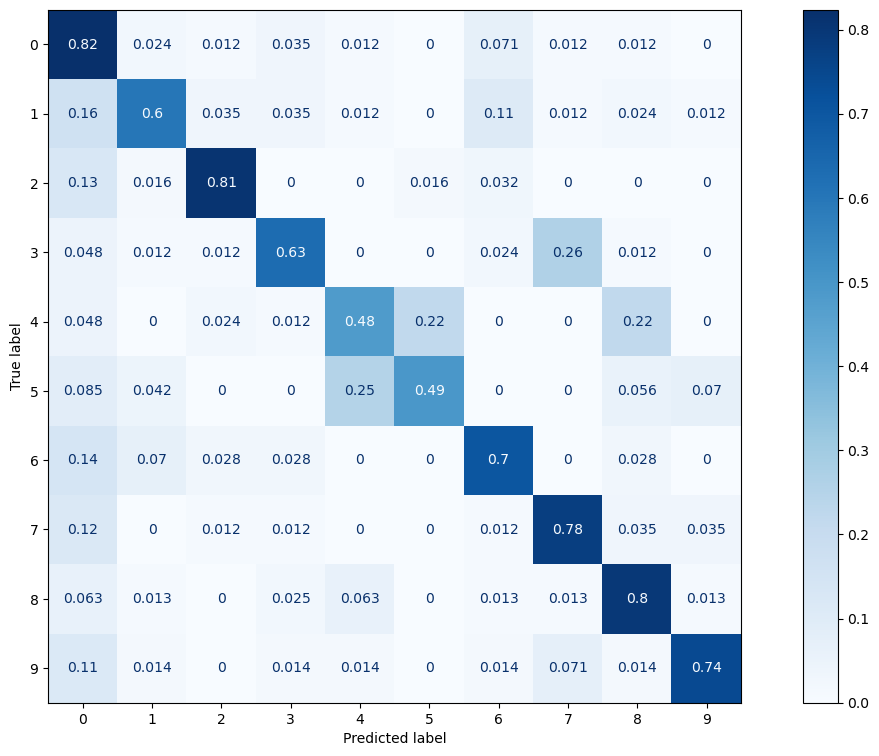

In [8]:
### START CODE HERE ###
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix, f1_score

train_set, test_set = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)


def get_labels_predictions(model, dataloader, device):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, predictions = torch.max(outputs, 1)

            all_labels.extend(labels.argmax(1).cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
        

    return all_labels, all_predictions

pos_labels = np.arange(10)

model = CustomLeNet().to(device)
model.load_state_dict(torch.load('/home/crueang/Chaks/image_processing-2024/Lab7_Data-Augmentation-CNN/cp/best_model.pth', weights_only=True, map_location=device))

lb, prd = get_labels_predictions(model, test_loader, device)

cm_target = confusion_matrix(y_true=lb,
                            y_pred=prd,
                            labels=pos_labels,
                            normalize='true',
                            )

fig, axs = plt.subplots(figsize=(16 ,9))
cm = metrics.ConfusionMatrixDisplay(cm_target)
cm.plot(ax=axs, cmap='Blues')

print(f'F1 score: {f1_score(lb, prd, average=None)}')
### END CODE HERE ###

Visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image

In [ ]:
### START CODE HERE ###
import math
import time
model.cpu()

class FeatureMapVisualizer:
    def __init__(self, model, layers, save_dir):
        """
        Parameters:
        - model: The PyTorch model
        - layers: A string or list of strings specifying the layer names to visualize
        - save_dir: Directory to save the output feature map images
        """
        self.model = model
        self.layers = layers if isinstance(layers, list) else [layers]
        self.activations = {}
        self.save_dir = save_dir

        os.makedirs(self.save_dir, exist_ok=True)

        self._register_hooks()

    def _register_hooks(self):
        for name, layer in self.model.named_modules():
            if name in self.layers:
                layer.register_forward_hook(self._hook_fn(name))

    def _hook_fn(self, layer_name):
        def hook(module, input, output):
            print(f'Hooking layer: {layer_name}')
            self.activations[layer_name] = output.detach()
        return hook

    def visualize(self, input_paths):
        """
        Pass an input tensor through the model and visualize the activations.
        
        Parameters:
        - input_paths: List of image paths to pass through the model
        """
        images = input_paths[0]
        labels = input_paths[1]
        for i in range(len(images)):
            self.model(images[i].unsqueeze(0))
            
            for layer_name, activation in self.activations.items():
                print(f'Visualizing and saving layer: {layer_name}')
                self._save_feature_maps(activation, layer_name, labels[i].argmax().item())

    def _save_feature_maps(self, activation, layer_name, label):
        ### START CODE HERE ###
        num_channels = activation.shape[1]
        grid_size = int(np.ceil(np.sqrt(num_channels)))
        
        fig, axs = plt.subplots(grid_size, grid_size, figsize=(15, 15))
        fig.suptitle(f'Feature Map {layer_name}', fontsize=16)
        fig.tight_layout()
        
        for j in range(num_channels):
            ax = axs[j // grid_size, j % grid_size]
            ax.imshow(self.activations[layer_name][0, j, :, :], cmap='gray')
            ax.axis('off')
            ax.set_title(f'ch {j+1}', fontsize=8)

        for j in range(num_channels, grid_size * grid_size):
            axs[j // grid_size, j % grid_size].axis('off')
        print(label)
        fig.savefig(f'{self.save_dir}/{label}/{layer_name}_{time.time()}.jpg')
        
        ### END CODE HERE ###

layer = ['layer1.0', 'layer2.0']

visualizer = FeatureMapVisualizer(model, layer,
                                  "/home/crueang/Chaks/image_processing-2024/Lab7_Data-Augmentation-CNN/outputs/")

while True:
    try:
        # Get the next item
        batch = next(iter(data_loader))
        visualizer.visualize(batch)
    except StopIteration:
        # StopIteration is raised when the iterator is exhausted
        print("End of iterator")
        break

### END CODE HERE ###

---
# Questions
1. Identify the top 3 classes with the worst F1 scores and perform an in-depth analysis of the model’s behavior on misclassified images. Analyze the feature map of an incorrectly predicted image from each class and compare it with the feature map of a correctly predicted image from the same class.
<br>class 0: 0.625, class 4: 0.53691275, class 5: 0.56
<br>class 4 และ 5 มีความคล้ายคลึงกันมาก และขั้นตอนการ preprocess มีการ translate ที่มากเกินไปทำให้ส่วนปลายของ 4 และ 5 บางตัวหลุดออกจากขอบไป ทำให้แยกไม่ได้
<br>class 0 dataset มีข้อมูลผิดพลาดเยอะมาก มีเลข 10 มีแม้กระทั่งรูปนก ทำให้โมเดลแยก class 0 ได้ยาก
2. Does a deeper model always lead to better performance? Discuss this by considering factors such as overfitting, training time, data complexity, and model capacity. Provide examples from relevant experiments to support your argument.
<br>= ไม่เสมอไป เพราะ <br>1. โมเดลที่ลึกเกินไปอาจทำให้จดจำรายละเอียดได้ดีเกินไป ทำให้ประสิทธิภาพในการประยุกต์เข้ากับข้อมูลใหม่ ๆ ลดลง 
<br> 2. training time ใช้มากขึ้น
<br> 3. data complexity ถ้าชุดข้อมูลไม่ซับซ้อนพอ โมเดลที่ลึกขึ้นก็ไม่จำเป็น และอาจทำให้ประสิทธิภาพลดลง
<br> 4. model capacity การเพิ่มความลึกของ model ไม่ได้ทำให้ประสิทธิภาพดีขึ้นเสมอไป และอาจทำให้ประสิทธิภาพลดลง
<br> ตัวอย่างเช่นในการเทรน MNIST (แยกเลข 0-9) โมเดลที่ลึกมาก ๆ อย่าง DenseNet-201 ชั้นก็ไม่ได้มีประสิทธิภาพดีกว่า Resnet-50

